
<div align="center">

![Course](https://img.shields.io/badge/Course-Advanced%20Data%20Science%20Lab-blue?style=for-the-badge&logo=python&logoColor=white)
![Code](https://img.shields.io/badge/Code-MCA33PE21-informational?style=for-the-badge)
![Case Study](https://img.shields.io/badge/FA2-Case%20Study-success?style=for-the-badge)

---

# Advanced Data Science Lab [MCA33PE21]
## FA2 Case Study
### Data Analysis Using Machine Learning & Streamlit App Deployment

---

| Field | Details |
|---|---|
| **Academic Year** | **2026 – 2027** |
| **Class / Division** | **SYMCA (Semester-I)** |
| **PRN** | **125M1H026** |
| **Student Name** | **Shantanu Suryawanshi** |
| **Submission Date** | **05-10-2026** |

</div>

---



# Case Study Overview

This case study develops a complete machine learning workflow for **student performance prediction** using the **Student Performance** dataset from the UCI Machine Learning Repository.

The selected dataset is appropriate for both **regression** and **classification**. The analysis therefore uses:

- **Linear Regression** to predict the final grade (`G3`).
- **Logistic Regression, Decision Tree, Random Forest, Support Vector Machine, K-Nearest Neighbors, and Naive Bayes** to classify students as **Pass** or **Fail**.
- **GridSearchCV** to tune the Random Forest classifier.
- A separate **Streamlit application** is provided as `app.py` for interactive prediction.

The notebook contains the complete implementation for **Part 1: Data Acquisition & Preprocessing** and **Part 2: Model Implementation & Evaluation**.



## Dataset Selection

### Student Performance — UCI Machine Learning Repository

The UCI Student Performance dataset contains demographic, social, school-related, study-related, and grade information for students from two Portuguese schools.

For this case study, the **Mathematics course dataset (`student-mat.csv`)** is used.

The final grade `G3` is the regression target. A binary classification target is derived from the same final grade:

- **Pass:** `G3 >= 10`
- **Fail:** `G3 < 10`

The UCI repository explicitly lists the Student Performance dataset for **classification and regression** tasks and provides the downloadable `student.zip` archive.

**Primary source:**  
https://archive.ics.uci.edu/dataset/320/student+performance



## Model Selection

The assignment requires at least four distinct algorithms. To provide a broader comparison while keeping the implementation focused, this case study uses seven algorithms:

| Task | Algorithm | Purpose |
|---|---|---|
| Regression | Linear Regression | Predict final grade |
| Classification | Logistic Regression | Pass/Fail classification |
| Classification | Decision Tree | Rule-based classification |
| Classification | Random Forest | Ensemble classification |
| Classification | Support Vector Machine | Margin-based classification |
| Classification | K-Nearest Neighbors | Distance-based classification |
| Classification | Naive Bayes | Probabilistic classification |

**Hyperparameter tuning:** GridSearchCV is applied to the Random Forest classifier using 5-fold cross-validation.



# Part 1: Data Acquisition & Preprocessing [05 Marks]

## 1. Dataset Loading and Initial Inspection

The dataset is downloaded from the UCI repository. A small public GitHub mirror is used only as a fallback so that the notebook remains usable if the primary archive is temporarily unavailable.

The workflow then:

1. Loads the Mathematics course data.
2. Inspects the first few records.
3. Checks shape, data types, and missing values.
4. Creates the binary Pass/Fail target for classification.


In [1]:

import io
import zipfile
from urllib.request import urlopen

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

RANDOM_STATE = 42

UCI_DATASET_URL = "https://archive.ics.uci.edu/static/public/320/student.zip"
FALLBACK_DATASET_URL = "https://raw.githubusercontent.com/gramener/datasets/main/student-mat.csv"

selected_features = [
    "age", "Medu", "Fedu", "studytime", "failures",
    "absences", "G1", "G2", "higher", "internet"
]

numeric_features = [
    "age", "Medu", "Fedu", "studytime", "failures",
    "absences", "G1", "G2"
]

categorical_features = ["higher", "internet"]



### Load the Mathematics Dataset

The UCI archive contains both Mathematics and Portuguese course files. The code selects `student-mat.csv`.


In [2]:

def load_student_data():
    try:
        with urlopen(UCI_DATASET_URL, timeout=30) as response:
            zip_data = io.BytesIO(response.read())

        with zipfile.ZipFile(zip_data) as archive:
            student_file = next(
                name for name in archive.namelist()
                if name.endswith("student-mat.csv")
            )
            with archive.open(student_file) as file:
                return pd.read_csv(file, sep=";")

    except Exception:
        with urlopen(FALLBACK_DATASET_URL, timeout=30) as response:
            return pd.read_csv(response, sep=";")


student_data = load_student_data()

print("Dataset loaded successfully.")
print("Dataset shape:", student_data.shape)
student_data.head()


Dataset loaded successfully.
Dataset shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


### Dataset Information

In [3]:

print("Column names:")
print(student_data.columns.tolist())

print("\nData types:")
print(student_data.dtypes)

print("\nDataset information:")
student_data.info()


Column names:
['school', 'sex', 'age', 'address', 'famsize', 'Pstatus', 'Medu', 'Fedu', 'Mjob', 'Fjob', 'reason', 'guardian', 'traveltime', 'studytime', 'failures', 'schoolsup', 'famsup', 'paid', 'activities', 'nursery', 'higher', 'internet', 'romantic', 'famrel', 'freetime', 'goout', 'Dalc', 'Walc', 'health', 'absences', 'G1', 'G2', 'G3']

Data types:
school          str
sex             str
age           int64
address         str
famsize         str
Pstatus         str
Medu          int64
Fedu          int64
Mjob            str
Fjob            str
reason          str
guardian        str
traveltime    int64
studytime     int64
failures      int64
schoolsup       str
famsup          str
paid            str
activities      str
nursery         str
higher          str
internet        str
romantic        str
famrel        int64
freetime      int64
goout         int64
Dalc          int64
Walc          int64
health        int64
absences      int64
G1            int64
G2            int64
G3   

### Missing Values

In [4]:

missing_values = student_data.isnull().sum()

print("Missing values by column:")
print(missing_values)

print("\nTotal missing values:", missing_values.sum())


Missing values by column:
school        0
sex           0
age           0
address       0
famsize       0
Pstatus       0
Medu          0
Fedu          0
Mjob          0
Fjob          0
reason        0
guardian      0
traveltime    0
studytime     0
failures      0
schoolsup     0
famsup        0
paid          0
activities    0
nursery       0
higher        0
internet      0
romantic      0
famrel        0
freetime      0
goout         0
Dalc          0
Walc          0
health        0
absences      0
G1            0
G2            0
G3            0
dtype: int64

Total missing values: 0



## 2. Exploratory Data Analysis

The following visualizations focus on the target and the most directly relevant academic variables:

- Distribution of final grade (`G3`).
- Relationship between first-period grade (`G1`) and final grade.
- Relationship between second-period grade (`G2`) and final grade.
- Final-grade distribution by weekly study time.
- Correlation heatmap for numerical variables.


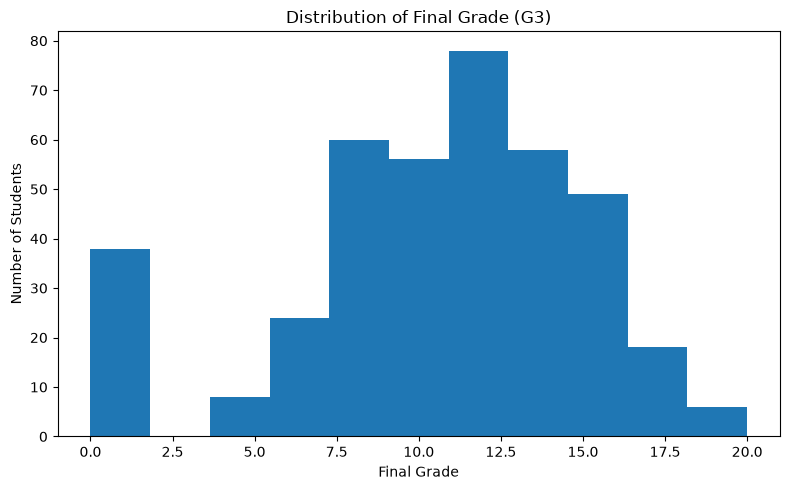

In [5]:

plt.figure(figsize=(8, 5))
plt.hist(student_data["G3"], bins=11)
plt.title("Distribution of Final Grade (G3)")
plt.xlabel("Final Grade")
plt.ylabel("Number of Students")
plt.tight_layout()
plt.show()


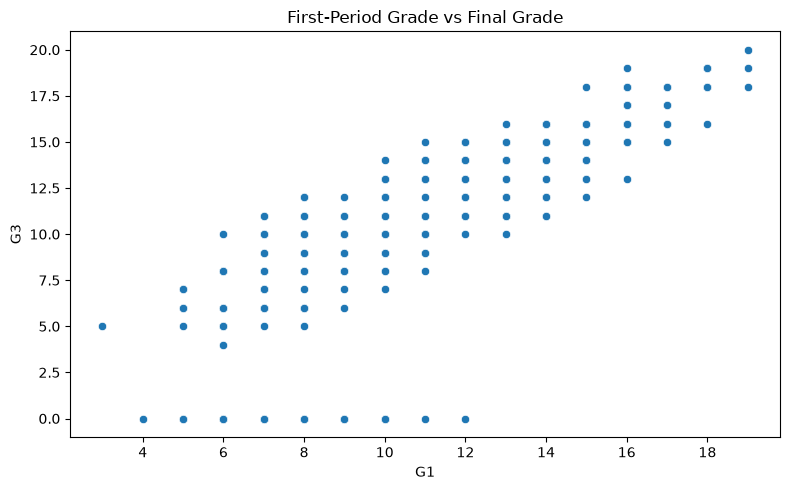

In [6]:

plt.figure(figsize=(8, 5))
sns.scatterplot(data=student_data, x="G1", y="G3")
plt.title("First-Period Grade vs Final Grade")
plt.xlabel("G1")
plt.ylabel("G3")
plt.tight_layout()
plt.show()


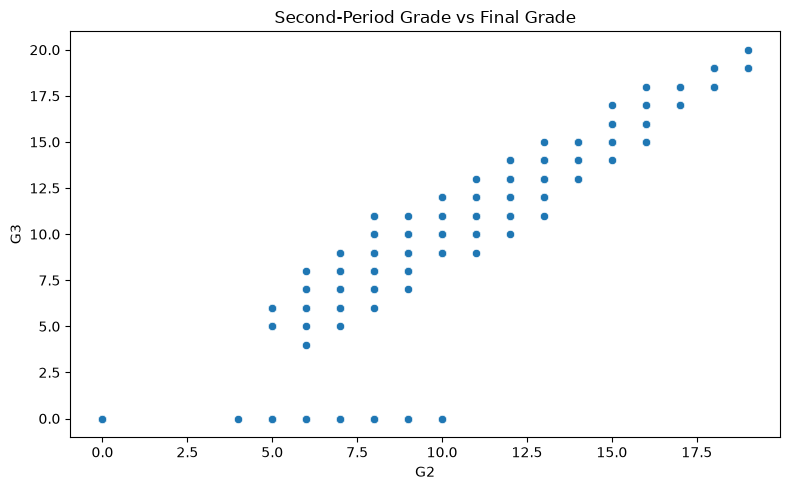

In [7]:

plt.figure(figsize=(8, 5))
sns.scatterplot(data=student_data, x="G2", y="G3")
plt.title("Second-Period Grade vs Final Grade")
plt.xlabel("G2")
plt.ylabel("G3")
plt.tight_layout()
plt.show()


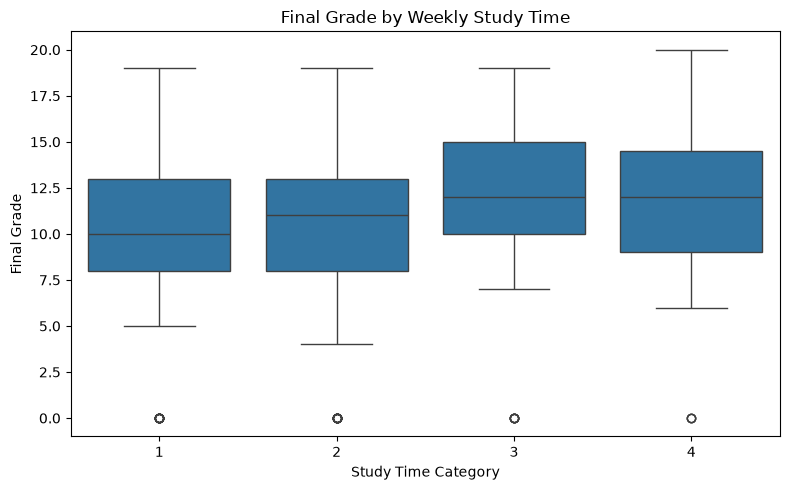

In [8]:

plt.figure(figsize=(8, 5))
sns.boxplot(data=student_data, x="studytime", y="G3")
plt.title("Final Grade by Weekly Study Time")
plt.xlabel("Study Time Category")
plt.ylabel("Final Grade")
plt.tight_layout()
plt.show()


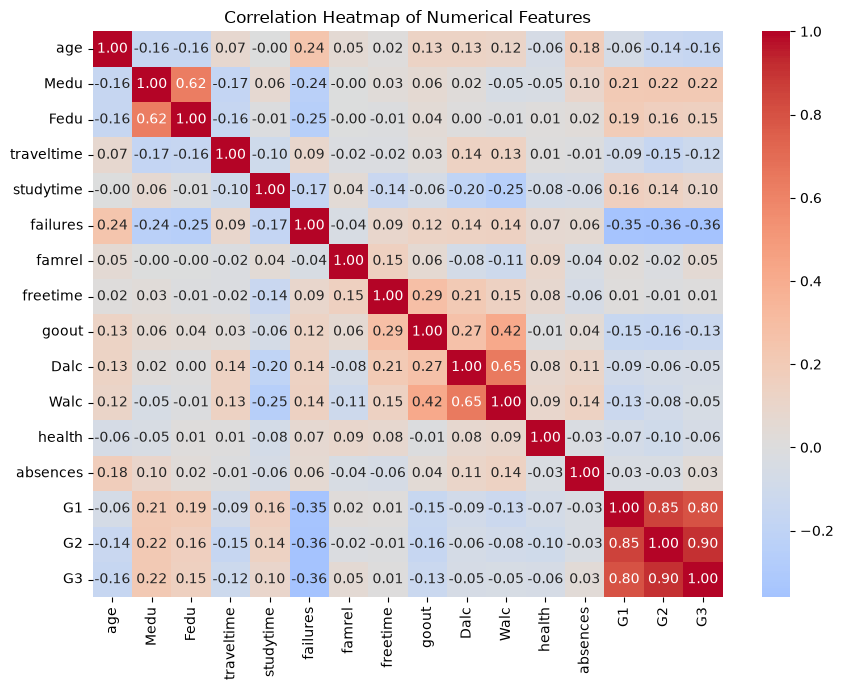

In [9]:

plt.figure(figsize=(9, 7))
correlation_data = student_data.select_dtypes(include=np.number).corr()

sns.heatmap(
    correlation_data,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.title("Correlation Heatmap of Numerical Features")
plt.tight_layout()
plt.show()



### EDA Findings

- `G1` and `G2` show a strong relationship with the final grade `G3`.
- Study time provides a useful behavioral variable for comparing student performance.
- The final grade is not uniformly distributed, so classification performance should be evaluated using more than accuracy alone.
- The dataset contains both numerical and categorical variables, making it suitable for demonstrating imputation, one-hot encoding, and feature scaling.



## 3. Feature Selection and Target Preparation

Ten features are selected to keep the models interpretable and the Streamlit interface practical.

The final grade `G3` is not included in the input features because it is the prediction target.

The classification target is derived from `G3` using the conventional passing threshold of 10.


In [10]:

student_data = student_data.copy()

student_data["pass_fail"] = np.where(
    student_data["G3"] >= 10,
    1,
    0
)

student_data["pass_label"] = student_data["pass_fail"].map({
    0: "Fail",
    1: "Pass"
})

X = student_data[selected_features]
y_regression = student_data["G3"]
y_classification = student_data["pass_fail"]

print("Selected features:")
print(selected_features)

print("\nClassification target distribution:")
print(student_data["pass_label"].value_counts())


Selected features:
['age', 'Medu', 'Fedu', 'studytime', 'failures', 'absences', 'G1', 'G2', 'higher', 'internet']

Classification target distribution:
pass_label
Pass    265
Fail    130
Name: count, dtype: int64



## 4. Train/Test Split

An 80/20 split is used as required by the case study.

The classification split is stratified so that the Pass/Fail proportion remains approximately consistent between training and testing data.


In [11]:

from sklearn.model_selection import train_test_split

X_regression_train, X_regression_test, y_regression_train, y_regression_test = train_test_split(
    X,
    y_regression,
    test_size=0.20,
    random_state=RANDOM_STATE
)

X_classification_train, X_classification_test, y_classification_train, y_classification_test = train_test_split(
    X,
    y_classification,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y_classification
)

print("Regression training samples:", len(X_regression_train))
print("Regression testing samples:", len(X_regression_test))
print("Classification training samples:", len(X_classification_train))
print("Classification testing samples:", len(X_classification_test))


Regression training samples: 316
Regression testing samples: 79
Classification training samples: 316
Classification testing samples: 79



## 5. Data Preprocessing

The preprocessing pipeline handles the two feature types separately:

- Numerical features: missing values are replaced by the median and values are standardized.
- Categorical features: missing values are replaced by the most frequent value and categories are one-hot encoded.

Using a `Pipeline` prevents preprocessing information from leaking from the test set into the training process.


In [12]:

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

try:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse_output=False
    )
except TypeError:
    one_hot_encoder = OneHotEncoder(
        handle_unknown="ignore",
        sparse=False
    )

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", one_hot_encoder)
])

preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features)
])

print("Preprocessing pipeline created successfully.")


Preprocessing pipeline created successfully.



# Part 2: Model Implementation & Evaluation [05 Marks]

## 1. Linear Regression

Linear Regression is used for the regression task because the target `G3` is a continuous numerical grade.

The model is evaluated using:

- Mean Absolute Error (MAE)
- Mean Squared Error (MSE)
- R² score


In [13]:

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

linear_regression_model = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LinearRegression())
])

linear_regression_model.fit(
    X_regression_train,
    y_regression_train
)

regression_predictions = linear_regression_model.predict(
    X_regression_test
)

regression_mae = mean_absolute_error(
    y_regression_test,
    regression_predictions
)

regression_mse = mean_squared_error(
    y_regression_test,
    regression_predictions
)

regression_r2 = r2_score(
    y_regression_test,
    regression_predictions
)

print("Linear Regression Results")
print("-------------------------")
print("MAE:", round(regression_mae, 3))
print("MSE:", round(regression_mse, 3))
print("R² :", round(regression_r2, 3))


Linear Regression Results
-------------------------
MAE: 1.333
MSE: 4.498
R² : 0.781


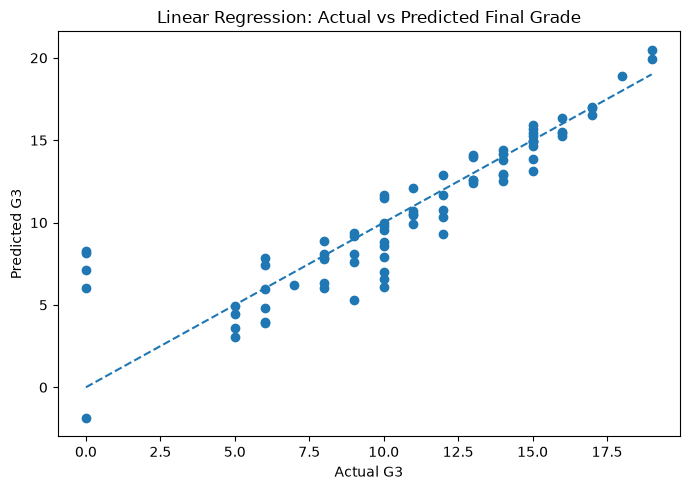

In [14]:

plt.figure(figsize=(7, 5))
plt.scatter(y_regression_test, regression_predictions)
plt.plot(
    [y_regression_test.min(), y_regression_test.max()],
    [y_regression_test.min(), y_regression_test.max()],
    linestyle="--"
)
plt.title("Linear Regression: Actual vs Predicted Final Grade")
plt.xlabel("Actual G3")
plt.ylabel("Predicted G3")
plt.tight_layout()
plt.show()



## 2. Classification Models

The following models predict whether a student passes or fails:

1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Support Vector Machine
5. K-Nearest Neighbors
6. Naive Bayes

The evaluation uses accuracy, precision, recall, and F1-score.


In [15]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

classification_models = {
    "Logistic Regression": LogisticRegression(
        max_iter=1000,
        random_state=RANDOM_STATE
    ),
    "Decision Tree": DecisionTreeClassifier(
        max_depth=5,
        random_state=RANDOM_STATE
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=150,
        random_state=RANDOM_STATE
    ),
    "Support Vector Machine": SVC(
        probability=True,
        random_state=RANDOM_STATE
    ),
    "K-Nearest Neighbors": KNeighborsClassifier(
        n_neighbors=7
    ),
    "Naive Bayes": GaussianNB()
}

trained_classification_models = {}
classification_results = []

for model_name, model in classification_models.items():
    model_pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    model_pipeline.fit(
        X_classification_train,
        y_classification_train
    )

    predictions = model_pipeline.predict(
        X_classification_test
    )

    accuracy = accuracy_score(
        y_classification_test,
        predictions
    )

    precision = precision_score(
        y_classification_test,
        predictions,
        zero_division=0
    )

    recall = recall_score(
        y_classification_test,
        predictions,
        zero_division=0
    )

    f1 = f1_score(
        y_classification_test,
        predictions,
        zero_division=0
    )

    trained_classification_models[model_name] = model_pipeline

    classification_results.append({
        "Model": model_name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1-Score": f1
    })

classification_results = pd.DataFrame(classification_results)

classification_results.sort_values(
    "F1-Score",
    ascending=False
).reset_index(drop=True)


C:\Users\ADMIN\AppData\Roaming\Python\Python314\site-packages\sklearn\svm\_base.py:239: FutureWarning: The `probability` parameter was deprecated in 1.9 and will be removed in version 1.11. Use `CalibratedClassifierCV(SVC(), ensemble=False)` instead of `SVC(probability=True)`
  warnings.warn(


,Model,Accuracy,Precision,Recall,F1-Score
0,Decision Tree,0.898734,0.941176,0.905660,0.923077
1,Support Vector Machine,0.898734,0.941176,0.905660,0.923077
2,Logistic Regression,0.898734,0.959184,0.886792,0.921569
3,Random Forest,0.886076,0.940000,0.886792,0.912621
4,Naive Bayes,0.873418,0.905660,0.905660,0.905660
5,K-Nearest Neighbors,0.822785,0.867925,0.867925,0.867925


### Classification Performance Comparison

In [17]:

classification_results_display = classification_results.copy()

for column_name in [
    "Accuracy",
    "Precision",
    "Recall",
    "F1-Score"
]:
    classification_results_display[column_name] = (
        classification_results_display[column_name].round(3)
    )

classification_results_display


,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.899,0.959,0.887,0.922
1,Decision Tree,0.899,0.941,0.906,0.923
2,Random Forest,0.886,0.940,0.887,0.913
3,Support Vector Machine,0.899,0.941,0.906,0.923
4,K-Nearest Neighbors,0.823,0.868,0.868,0.868
5,Naive Bayes,0.873,0.906,0.906,0.906


<Figure size 1000x500 with 0 Axes>

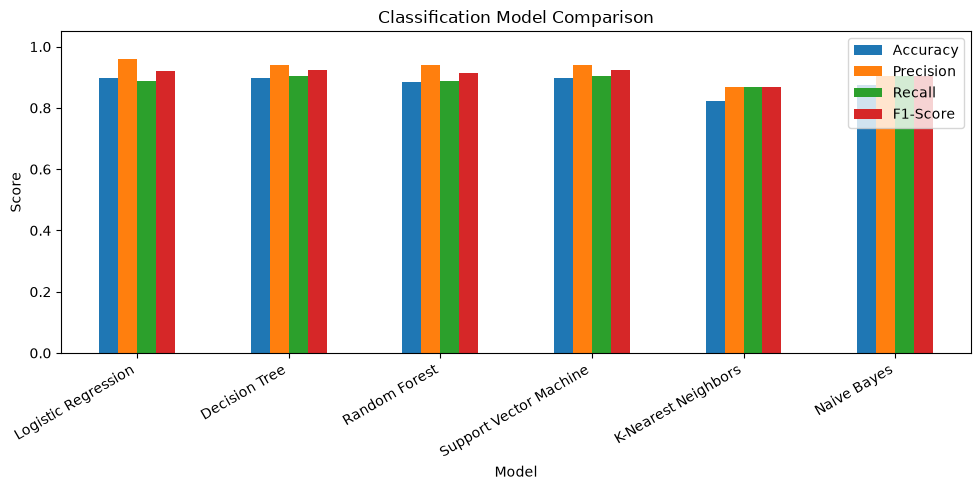

In [16]:

plt.figure(figsize=(10, 5))

plot_data = classification_results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
]

plot_data.plot(kind="bar", figsize=(10, 5))

plt.title("Classification Model Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()



## 3. Confusion Matrices and Classification Reports

A confusion matrix shows the number of:

- True Negatives
- False Positives
- False Negatives
- True Positives

The classification report provides precision, recall, and F1-score for both classes.



Logistic Regression
              precision    recall  f1-score   support

        Fail       0.80      0.92      0.86        26
        Pass       0.96      0.89      0.92        53

    accuracy                           0.90        79
   macro avg       0.88      0.90      0.89        79
weighted avg       0.91      0.90      0.90        79



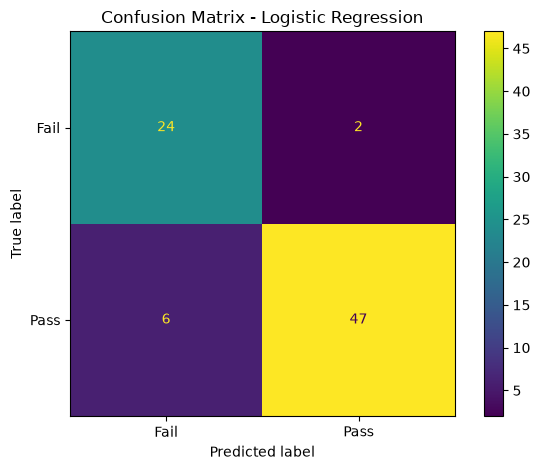


Decision Tree
              precision    recall  f1-score   support

        Fail       0.82      0.88      0.85        26
        Pass       0.94      0.91      0.92        53

    accuracy                           0.90        79
   macro avg       0.88      0.90      0.89        79
weighted avg       0.90      0.90      0.90        79



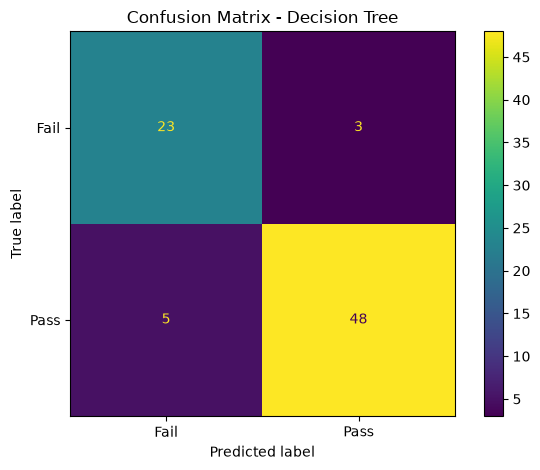


Random Forest
              precision    recall  f1-score   support

        Fail       0.79      0.88      0.84        26
        Pass       0.94      0.89      0.91        53

    accuracy                           0.89        79
   macro avg       0.87      0.89      0.87        79
weighted avg       0.89      0.89      0.89        79



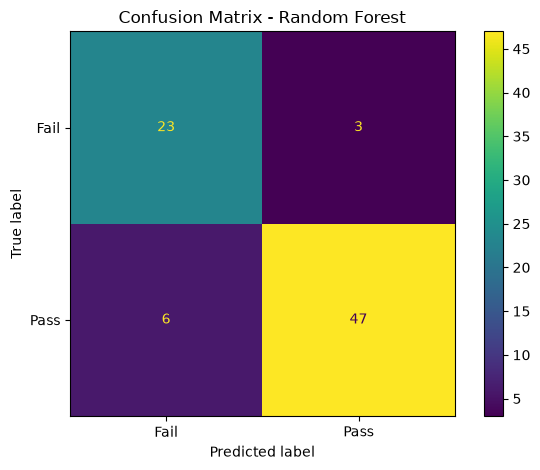


Support Vector Machine
              precision    recall  f1-score   support

        Fail       0.82      0.88      0.85        26
        Pass       0.94      0.91      0.92        53

    accuracy                           0.90        79
   macro avg       0.88      0.90      0.89        79
weighted avg       0.90      0.90      0.90        79



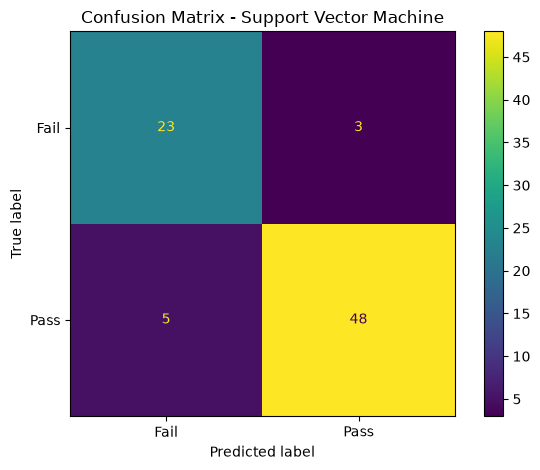


K-Nearest Neighbors
              precision    recall  f1-score   support

        Fail       0.73      0.73      0.73        26
        Pass       0.87      0.87      0.87        53

    accuracy                           0.82        79
   macro avg       0.80      0.80      0.80        79
weighted avg       0.82      0.82      0.82        79



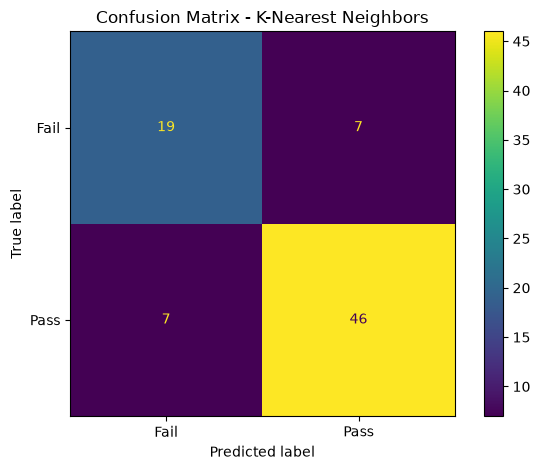


Naive Bayes
              precision    recall  f1-score   support

        Fail       0.81      0.81      0.81        26
        Pass       0.91      0.91      0.91        53

    accuracy                           0.87        79
   macro avg       0.86      0.86      0.86        79
weighted avg       0.87      0.87      0.87        79



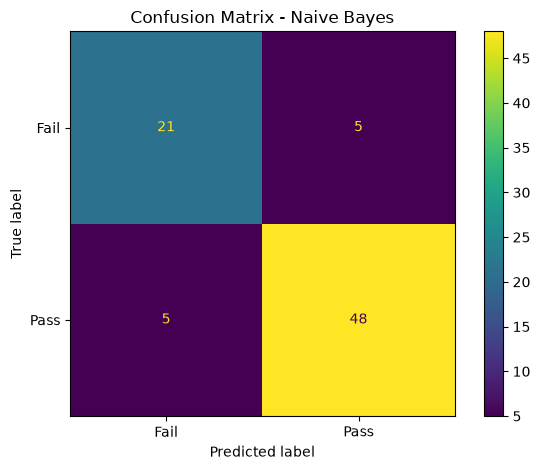

In [18]:

from sklearn.metrics import ConfusionMatrixDisplay, classification_report

for model_name, model_pipeline in trained_classification_models.items():
    predictions = model_pipeline.predict(X_classification_test)

    print("\n" + "=" * 70)
    print(model_name)
    print("=" * 70)
    print(classification_report(
        y_classification_test,
        predictions,
        target_names=["Fail", "Pass"],
        zero_division=0
    ))

    ConfusionMatrixDisplay.from_predictions(
        y_classification_test,
        predictions,
        display_labels=["Fail", "Pass"]
    )

    plt.title(f"Confusion Matrix - {model_name}")
    plt.tight_layout()
    plt.show()



# 4. Hyperparameter Tuning with GridSearchCV

Random Forest is selected for tuning because it is a strong ensemble baseline and provides several meaningful hyperparameters.

The search uses:

- `n_estimators`
- `max_depth`
- `min_samples_split`

A **5-fold cross-validation** strategy is used, as required by the case study.


In [19]:

from sklearn.model_selection import GridSearchCV

random_forest_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        random_state=RANDOM_STATE
    ))
])

parameter_grid = {
    "model__n_estimators": [100, 150],
    "model__max_depth": [None, 5, 10],
    "model__min_samples_split": [2, 5]
}

grid_search = GridSearchCV(
    estimator=random_forest_pipeline,
    param_grid=parameter_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

grid_search.fit(
    X_classification_train,
    y_classification_train
)

print("Best parameters:")
print(grid_search.best_params_)

print("\nBest cross-validation accuracy:")
print(round(grid_search.best_score_, 3))


Best parameters:
{'model__max_depth': 5, 'model__min_samples_split': 5, 'model__n_estimators': 150}

Best cross-validation accuracy:
0.937


In [20]:

tuned_random_forest = grid_search.best_estimator_

tuned_predictions = tuned_random_forest.predict(
    X_classification_test
)

tuned_accuracy = accuracy_score(
    y_classification_test,
    tuned_predictions
)

tuned_precision = precision_score(
    y_classification_test,
    tuned_predictions,
    zero_division=0
)

tuned_recall = recall_score(
    y_classification_test,
    tuned_predictions,
    zero_division=0
)

tuned_f1 = f1_score(
    y_classification_test,
    tuned_predictions,
    zero_division=0
)

print("Tuned Random Forest Test Results")
print("--------------------------------")
print("Accuracy :", round(tuned_accuracy, 3))
print("Precision:", round(tuned_precision, 3))
print("Recall   :", round(tuned_recall, 3))
print("F1-Score :", round(tuned_f1, 3))


Tuned Random Forest Test Results
--------------------------------
Accuracy : 0.873
Precision: 0.957
Recall   : 0.849
F1-Score : 0.9


### Default Random Forest vs Tuned Random Forest

In [21]:

default_random_forest_accuracy = classification_results.loc[
    classification_results["Model"] == "Random Forest",
    "Accuracy"
].iloc[0]

comparison = pd.DataFrame({
    "Model": [
        "Default Random Forest",
        "Tuned Random Forest"
    ],
    "Test Accuracy": [
        default_random_forest_accuracy,
        tuned_accuracy
    ]
})

comparison["Test Accuracy"] = comparison["Test Accuracy"].round(3)
comparison


,Model,Test Accuracy
0,Default Random Forest,0.886
1,Tuned Random Forest,0.873


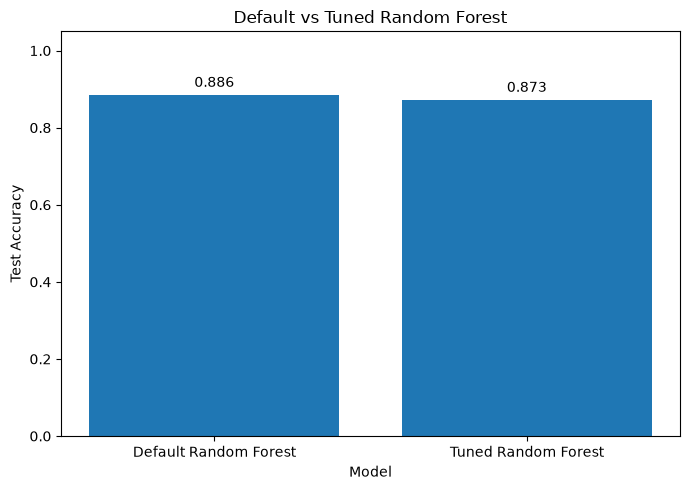

In [22]:

plt.figure(figsize=(7, 5))

plt.bar(
    comparison["Model"],
    comparison["Test Accuracy"]
)

plt.title("Default vs Tuned Random Forest")
plt.xlabel("Model")
plt.ylabel("Test Accuracy")
plt.ylim(0, 1.05)

for index, value in enumerate(comparison["Test Accuracy"]):
    plt.text(
        index,
        value + 0.02,
        f"{value:.3f}",
        ha="center"
    )

plt.tight_layout()
plt.show()



# 5. Final Findings and Insights

### Data and preprocessing

- The selected UCI dataset is suitable for both regression and classification.
- The workflow handles numerical and categorical variables separately.
- Missing-value handling, one-hot encoding, and scaling are performed inside a preprocessing pipeline.

### Regression

Linear Regression provides a direct baseline for predicting the continuous final grade `G3`. MAE, MSE, and R² provide complementary views of prediction error and explanatory performance.

### Classification

The six classification algorithms provide different modelling strategies. Accuracy alone is not sufficient when Pass/Fail class proportions differ, so precision, recall, and F1-score are reported as well.

### Hyperparameter tuning

GridSearchCV evaluates multiple Random Forest configurations using 5-fold cross-validation. The tuned model is then evaluated on the untouched test set.

The exact numerical results are generated directly from the downloaded UCI dataset when this notebook is executed.



# Part 3: Streamlit Deployment [05 Marks]

The separate `app.py` file implements the interactive web application required by the case study.

The application:

1. Loads the same UCI Mathematics dataset.
2. Trains the same preprocessing and machine learning pipelines when model files are not yet available.
3. Saves the trained pipelines using `joblib`.
4. Loads saved pipelines on subsequent runs.
5. Provides user-friendly widgets for the selected features.
6. Supports final-grade regression and Pass/Fail classification.
7. Allows the user to select a classification model.
8. Displays the generated prediction clearly.

The application is designed so that it can be deployed directly to **Streamlit Community Cloud**. The dataset is downloaded at runtime, so no separate dataset file is required in the submission.



# Part 4: Submission Files [05 Marks]

The case study submission consists of:

1. **Jupyter Notebook** — this file, containing Part 1 and Part 2.
2. **`app.py`** — the Streamlit application for Part 3.
3. **PDF Report** — concise summary of dataset selection, preprocessing, models, evaluation, tuning, findings, and deployment.

**Dataset source:** UCI Machine Learning Repository — Student Performance  
**Primary source:** https://archive.ics.uci.edu/dataset/320/student+performance



---

<div align="center">

### Declaration

_I hereby declare that the work submitted in this practical assignment is my own and has not been copied from any other source._

| | |
|---|---|
| **Student Name** | Shantanu Suryawanshi |
| **PRN** | 125M1H026 |
| **Date** | 05-10-2026 |

---

**Prof. Prakash Ukhalkar**  
Course Teacher - Advanced Data Science Lab [MCA33PE21]

</div>
